# Notebook 3 — EMD decomposition of the news sentiment index

Цель ноутбука — проверить структуру **дневного новостного индекса** `I_t`, который используется в регрессиях и корреляционном анализе.

Что делает ноутбук:

1. загружает дневные признаки из `data/final_features_all_extended.parquet` или `data/final_features_all.parquet`;
2. для каждого тикера выполняет EMD-разложение ряда `I_t`;
3. считает нормированные энергетические доли IMF-компонент;
4. отдельно считает долю высокочастотной части сигнала: `IMF1 + IMF2`;
5. сохраняет таблицы и графики в `outputs/`.

Важно: EMD-компоненты не являются строго ортогональными, поэтому доли вида `var(IMF_k) / var(x)` могут быть больше 1 и плохо интерпретируются как «доли дисперсии». Поэтому ниже используется нормировка по суммарной энергии всех IMF и остатка.


In [1]:
# --- Imports and optional PyEMD installation ---
import sys
import subprocess
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

def pip_install(pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)

try:
    from PyEMD import EMD
except Exception:
    pip_install(["EMD-signal"])
    from PyEMD import EMD

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("data")
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

print("Ready.")


Ready.


In [2]:
# --- Robust parquet loader ---
_PARQUET_ENGINE = None
try:
    import fastparquet  # noqa: F401
    _PARQUET_ENGINE = "fastparquet"
except Exception:
    _PARQUET_ENGINE = "pyarrow"

def _reset_pyarrow_pandas_ext_types():
    try:
        import pyarrow as pa
    except Exception:
        return
    for name in ("pandas.period", "pandas.interval"):
        try:
            pa.unregister_extension_type(name)
        except Exception:
            pass

def safe_read_parquet(path: Path) -> pd.DataFrame:
    try:
        return pd.read_parquet(path, engine=_PARQUET_ENGINE)
    except Exception as e:
        msg = str(e)
        if ("type extension with name pandas." in msg and "already defined" in msg) or "ArrowKeyError" in msg:
            _reset_pyarrow_pandas_ext_types()
            return pd.read_parquet(path, engine=_PARQUET_ENGINE)
        raise

print("Parquet engine:", _PARQUET_ENGINE)


Parquet engine: pyarrow


In [3]:
# --- Load daily final features ---
candidate_paths = [
    DATA_DIR / "final_features_all_extended.parquet",
    DATA_DIR / "final_features_all.parquet",
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "Daily feature file not found. Expected one of: "
        + ", ".join(str(p) for p in candidate_paths)
    )

df = safe_read_parquet(data_path).copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

required_cols = {"ticker", "date", "I_t"}
missing = required_cols - set(df.columns)
if missing:
    raise RuntimeError(f"Missing required columns: {missing}")

# Use only tickers with non-empty I_t series
tickers = sorted(df["ticker"].dropna().unique())
print("Loaded:", data_path)
print("Rows:", len(df), "Date range:", df["date"].min(), "—", df["date"].max())
print("Tickers:", tickers)
print("Columns containing news indices:", [c for c in df.columns if c.startswith("I_") or c.startswith("n_") or "sent" in c.lower()])


Loaded: data/final_features_all_extended.parquet
Rows: 2512 Date range: 2020-12-29 00:00:00 — 2025-12-29 00:00:00
Tickers: ['AAPL', 'XOM']
Columns containing news indices: ['I_t', 'I_t_max', 'n_news', 'I_t_pos', 'I_t_neg']


## EMD helper functions

Ниже функция `run_emd_for_ticker` делает разложение одного дневного ряда.  
По умолчанию анализируется `I_t`, потому что именно этот индекс используется в дневной части исследования.

Если в данных есть расширенные индексы, например `I_firm`, `I_market`, `I_sector`, можно вызвать эту же функцию для каждого из них.


In [4]:
def prepare_regular_daily_series(
    data: pd.DataFrame,
    ticker: str,
    series_col: str = "I_t",
    fill_missing_dates: bool = False,
) -> pd.DataFrame:
    """Return sorted daily series for one ticker.

    For the main thesis analysis we keep the trading-day grid from price data.
    Missing news values are interpreted as neutral news background and filled with 0.
    Optionally, a calendar daily grid can be created, but this is usually not needed
    for trading-day regressions.
    """
    g = data.loc[data["ticker"] == ticker, ["date", series_col]].copy()
    g = g.sort_values("date").drop_duplicates("date")

    if fill_missing_dates:
        idx = pd.date_range(g["date"].min(), g["date"].max(), freq="D")
        g = g.set_index("date").reindex(idx).rename_axis("date").reset_index()

    g[series_col] = pd.to_numeric(g[series_col], errors="coerce").fillna(0.0)

    # Remove constant/near-constant series early
    if g[series_col].std(ddof=0) < 1e-12:
        raise RuntimeError(f"{ticker} {series_col}: series is constant or almost constant.")

    return g


def emd_energy_table(x: np.ndarray, imfs: np.ndarray, residual: np.ndarray) -> pd.DataFrame:
    """Compute normalized component energy.

    EMD is adaptive and IMFs are not guaranteed to be orthogonal.
    Therefore var(IMF_k) / var(x) is not a reliable share and may exceed 1.
    We normalize each component's squared-energy by the sum of squared energies
    of all IMFs and the residual.
    """
    components = []
    for i in range(imfs.shape[0]):
        components.append((f"IMF{i+1}", imfs[i]))
    components.append(("Residual", residual))

    rows = []
    total_energy = sum(float(np.sum(c ** 2)) for _, c in components)
    total_variance_proxy = sum(float(np.var(c)) for _, c in components)

    for name, comp in components:
        energy = float(np.sum(comp ** 2))
        variance = float(np.var(comp))
        rows.append({
            "component": name,
            "energy": energy,
            "energy_share": energy / total_energy if total_energy > 0 else np.nan,
            "variance": variance,
            "variance_share_normalized": variance / total_variance_proxy if total_variance_proxy > 0 else np.nan,
            "std": float(np.std(comp)),
        })

    tbl = pd.DataFrame(rows)
    return tbl


def run_emd_for_ticker(
    data: pd.DataFrame,
    ticker: str,
    series_col: str = "I_t",
    max_imfs_to_plot: int = 6,
    fill_missing_dates: bool = False,
):
    g = prepare_regular_daily_series(data, ticker, series_col, fill_missing_dates=fill_missing_dates)
    tvals = pd.to_datetime(g["date"]).dt.tz_localize(None)
    x = g[series_col].to_numpy(dtype=float)

    # EMD works better when the signal is centered; this does not change oscillatory structure.
    x_centered = x - np.mean(x)

    emd = EMD()
    imfs = emd.emd(x_centered)

    if imfs is None or len(imfs) == 0:
        raise RuntimeError(f"{ticker} {series_col}: EMD returned no IMFs.")

    imfs = np.asarray(imfs)
    residual = x_centered - imfs.sum(axis=0)

    tbl = emd_energy_table(x_centered, imfs, residual)
    tbl.insert(0, "ticker", ticker)
    tbl.insert(1, "series", series_col)

    high_freq_share = tbl.loc[tbl["component"].isin(["IMF1", "IMF2"]), "energy_share"].sum()
    low_freq_share = tbl.loc[tbl["component"].isin(["Residual"]), "energy_share"].sum()

    summary = {
        "ticker": ticker,
        "series": series_col,
        "n_obs": len(g),
        "n_imfs": imfs.shape[0],
        "mean": float(np.mean(x)),
        "std": float(np.std(x)),
        "high_freq_energy_share_IMF1_IMF2": float(high_freq_share),
        "residual_energy_share": float(low_freq_share),
        "start_date": g["date"].min(),
        "end_date": g["date"].max(),
    }

    # Save table
    table_path = OUT_DIR / f"emd_energy_{ticker}_{series_col}.csv"
    tbl.to_csv(table_path, index=False)

    # Plot
    n_show = min(max_imfs_to_plot, imfs.shape[0])
    n_rows = 2 + n_show
    fig, axes = plt.subplots(n_rows, 1, figsize=(12, 2.2 * n_rows), sharex=True)

    axes[0].plot(tvals, x_centered)
    axes[0].set_title(f"{ticker}: centered daily news sentiment index ({series_col})")

    for i in range(n_show):
        axes[i + 1].plot(tvals, imfs[i])
        share = tbl.loc[tbl["component"] == f"IMF{i+1}", "energy_share"].iloc[0]
        axes[i + 1].set_title(f"IMF {i+1}, energy_share={share:.3f}")

    axes[n_show + 1].plot(tvals, residual)
    residual_share = tbl.loc[tbl["component"] == "Residual", "energy_share"].iloc[0]
    axes[n_show + 1].set_title(f"Residual, energy_share={residual_share:.3f}")

    fig.tight_layout()
    fig_path = OUT_DIR / f"emd_{ticker}_{series_col}_daily.png"
    fig.savefig(fig_path, dpi=150)
    plt.show()

    print(f"Saved table: {table_path}")
    print(f"Saved figure: {fig_path}")
    print("Summary:", summary)

    return g, imfs, residual, tbl, summary


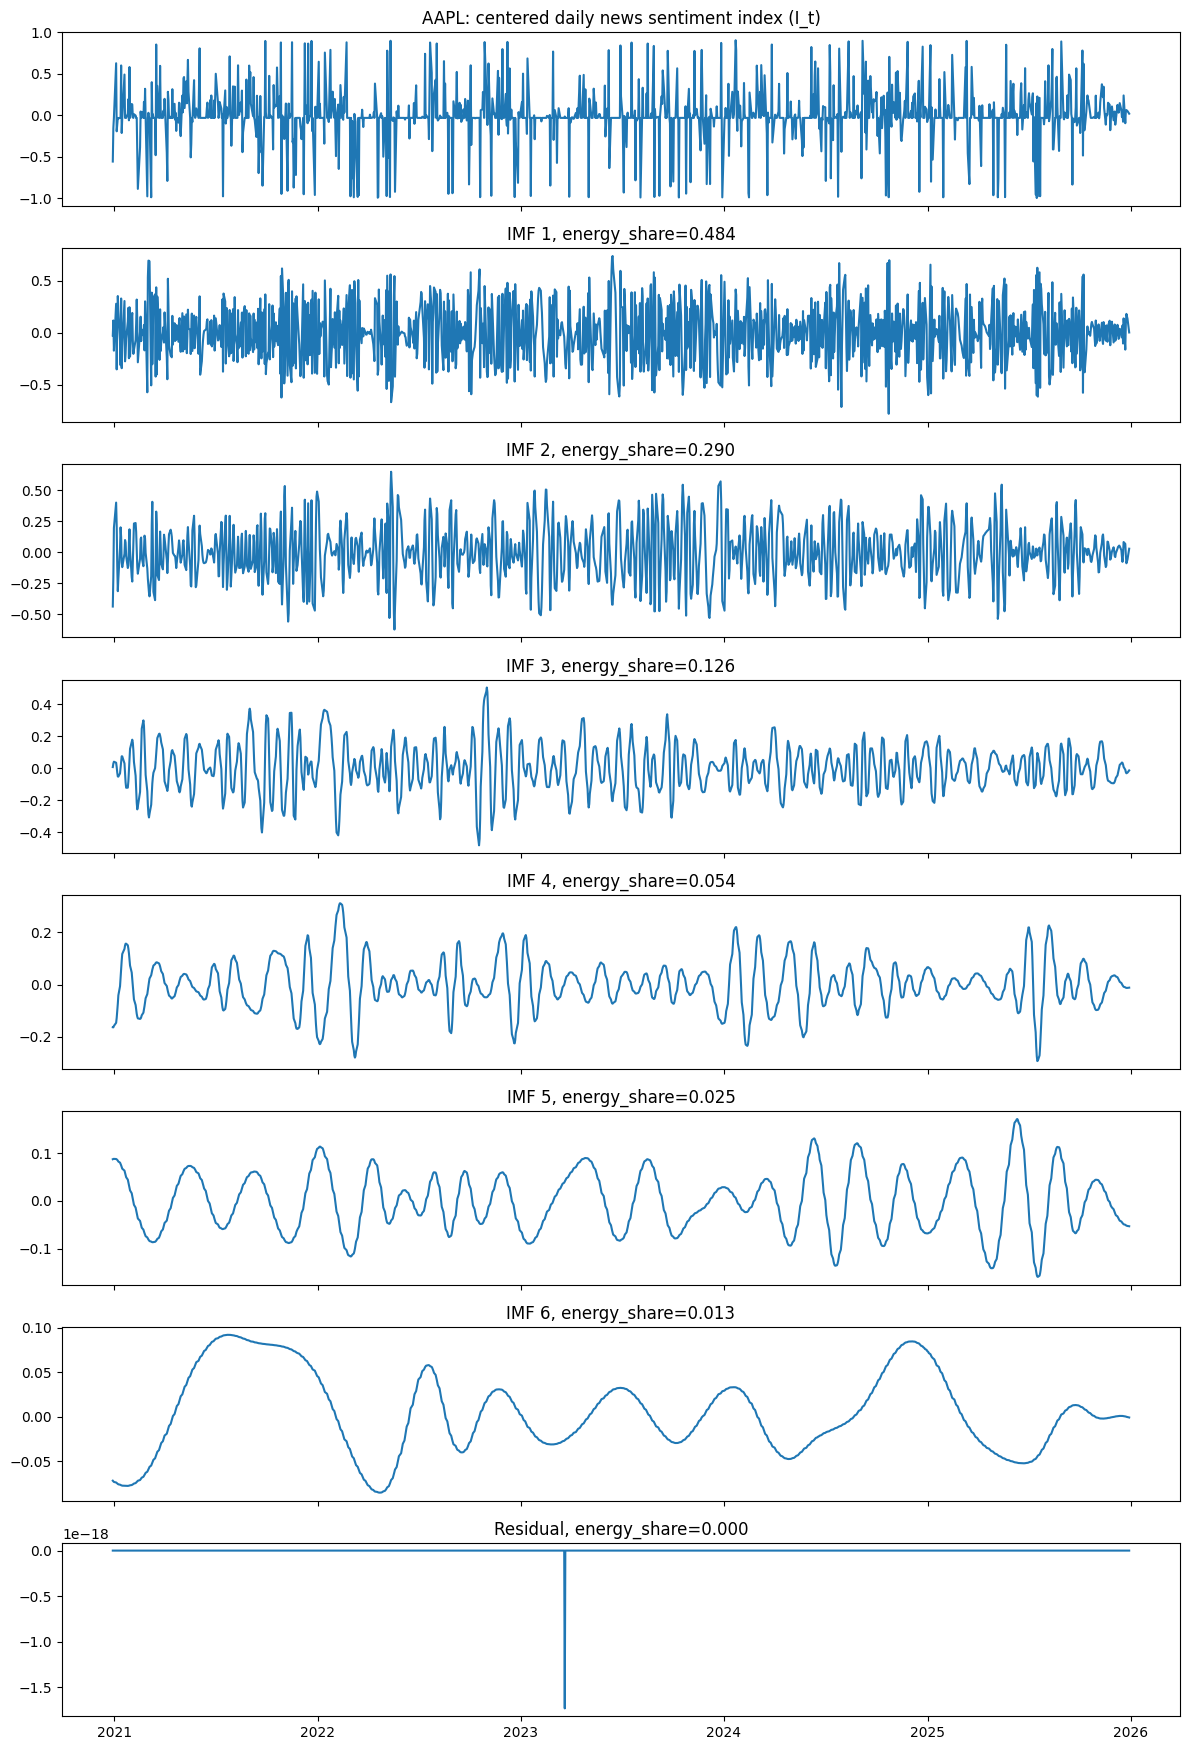

Saved table: outputs/emd_energy_AAPL_I_t.csv
Saved figure: outputs/emd_AAPL_I_t_daily.png
Summary: {'ticker': 'AAPL', 'series': 'I_t', 'n_obs': 1256, 'n_imfs': 8, 'mean': 0.030894350237880425, 'std': 0.32874820644579306, 'high_freq_energy_share_IMF1_IMF2': 0.7732438944693208, 'residual_energy_share': 1.5437043273582466e-38, 'start_date': Timestamp('2020-12-29 00:00:00'), 'end_date': Timestamp('2025-12-29 00:00:00')}


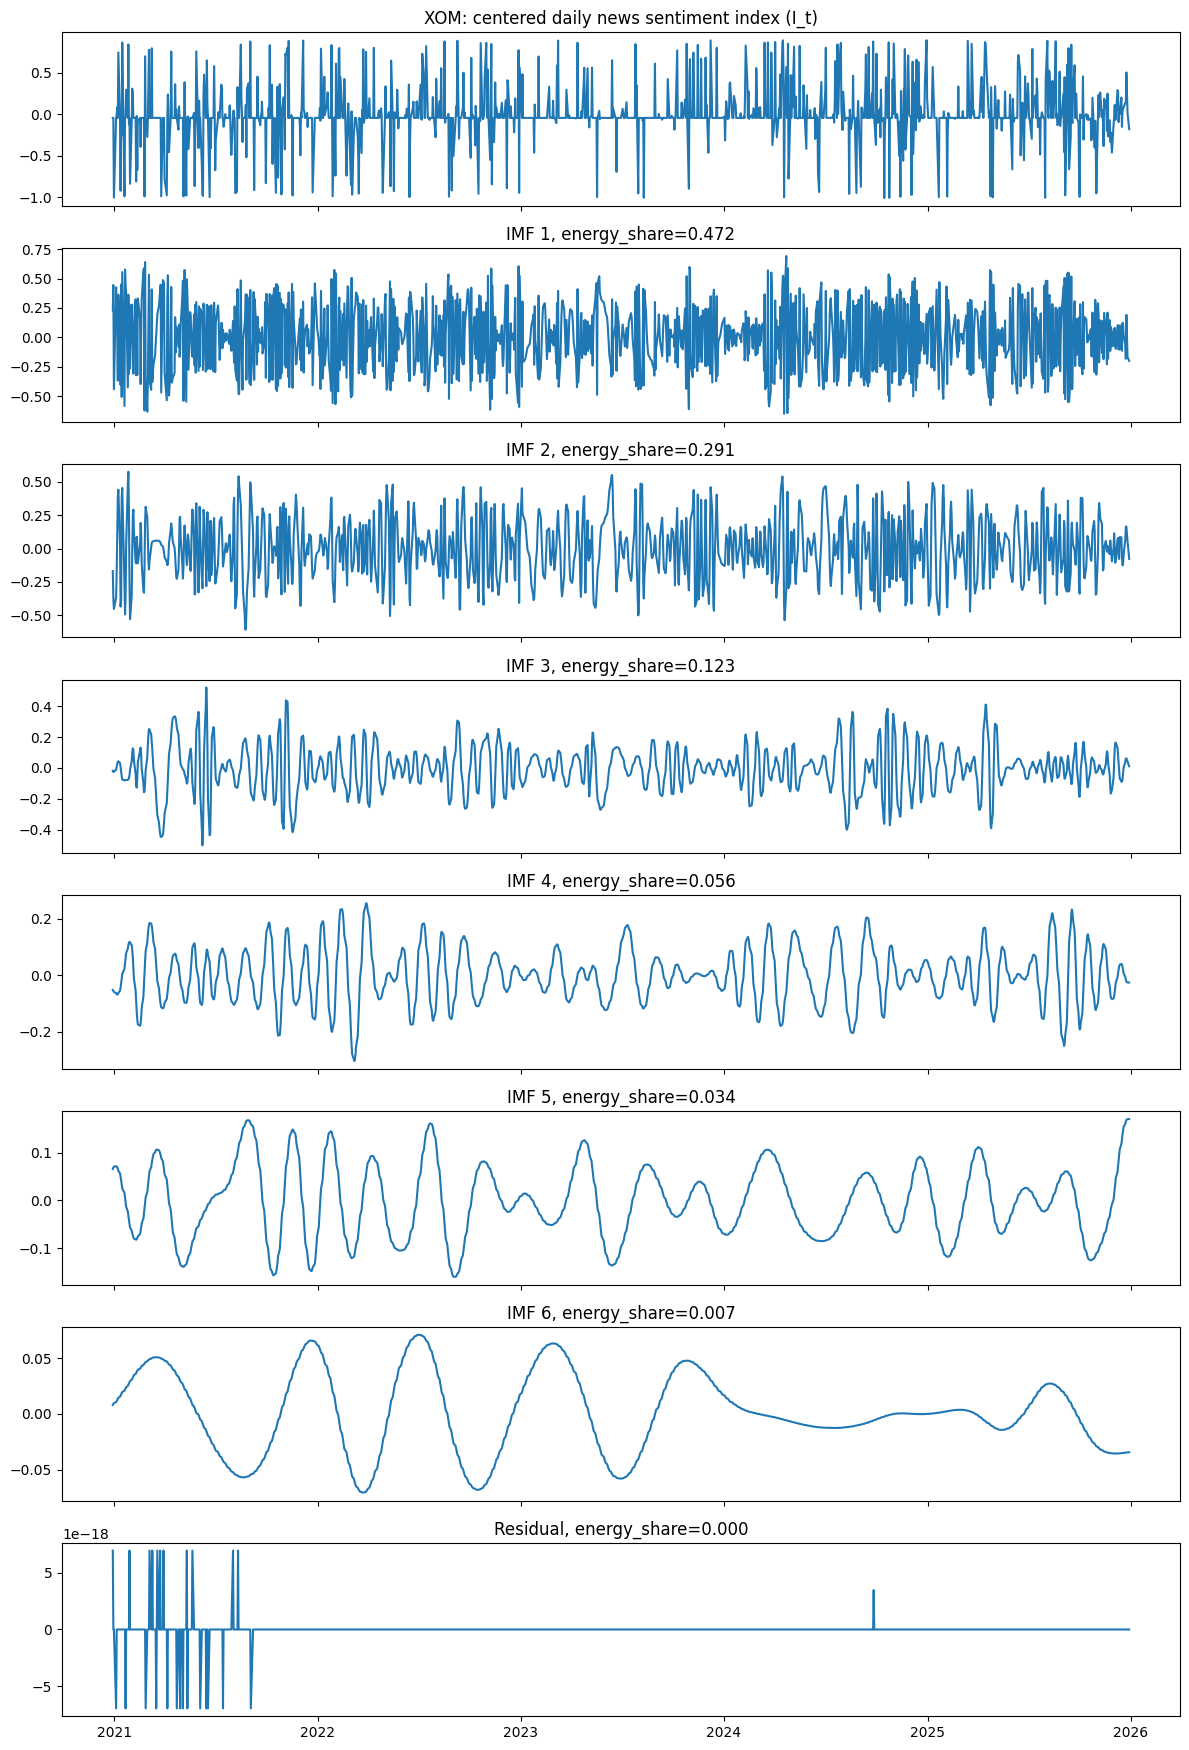

Saved table: outputs/emd_energy_XOM_I_t.csv
Saved figure: outputs/emd_XOM_I_t_daily.png
Summary: {'ticker': 'XOM', 'series': 'I_t', 'n_obs': 1256, 'n_imfs': 8, 'mean': 0.04438729051728199, 'std': 0.3436978554661317, 'high_freq_energy_share_IMF1_IMF2': 0.7632883864859206, 'residual_energy_share': 5.909318100299032e-36, 'start_date': Timestamp('2020-12-29 00:00:00'), 'end_date': Timestamp('2025-12-29 00:00:00')}


,ticker,series,n_obs,n_imfs,mean,std,high_freq_energy_share_IMF1_IMF2,residual_energy_share,start_date,end_date
0,AAPL,I_t,1256,8,0.030894,0.328748,0.773244,1.543704e-38,2020-12-29,2025-12-29
1,XOM,I_t,1256,8,0.044387,0.343698,0.763288,5.909318e-36,2020-12-29,2025-12-29


In [5]:
# --- Run EMD for the main daily news index I_t for all tickers ---
all_tables = []
all_summaries = []

for ticker in tickers:
    try:
        g, imfs, residual, tbl, summary = run_emd_for_ticker(
            df,
            ticker=ticker,
            series_col="I_t",
            max_imfs_to_plot=6,
            fill_missing_dates=False,
        )
        all_tables.append(tbl)
        all_summaries.append(summary)
    except Exception as e:
        print(f"Skipping {ticker}: {e}")

emd_summary = pd.DataFrame(all_summaries)
emd_summary.to_csv(OUT_DIR / "emd_summary_daily_I_t.csv", index=False)

emd_components = pd.concat(all_tables, ignore_index=True) if all_tables else pd.DataFrame()
if not emd_components.empty:
    emd_components.to_csv(OUT_DIR / "emd_components_daily_I_t.csv", index=False)

emd_summary


## Optional: EMD for extended news indices

Если после расширения пайплайна появятся отдельные индексы `I_firm`, `I_market`, `I_sector`, то этот блок позволит сравнить их частотную структуру.

Это полезно для проверки гипотезы: company-specific новости могут быть более дискретными и высокочастотными, а market-wide или sector-specific фон — более устойчивым и низкочастотным.


In [6]:
# --- Optional: run EMD for extended indices if they exist ---
candidate_series = ["I_firm", "I_market", "I_sector"]
available_series = [c for c in candidate_series if c in df.columns]

extended_summaries = []
extended_tables = []

if not available_series:
    print("No extended news index columns found yet:", candidate_series)
else:
    for series_col in available_series:
        for ticker in tickers:
            try:
                g, imfs, residual, tbl, summary = run_emd_for_ticker(
                    df,
                    ticker=ticker,
                    series_col=series_col,
                    max_imfs_to_plot=6,
                    fill_missing_dates=False,
                )
                extended_tables.append(tbl)
                extended_summaries.append(summary)
            except Exception as e:
                print(f"Skipping {ticker} {series_col}: {e}")

    emd_extended_summary = pd.DataFrame(extended_summaries)
    emd_extended_summary.to_csv(OUT_DIR / "emd_summary_extended_indices.csv", index=False)

    emd_extended_components = pd.concat(extended_tables, ignore_index=True) if extended_tables else pd.DataFrame()
    if not emd_extended_components.empty:
        emd_extended_components.to_csv(OUT_DIR / "emd_components_extended_indices.csv", index=False)

    display(emd_extended_summary)


No extended news index columns found yet: ['I_firm', 'I_market', 'I_sector']


## Interpretation template

После выполнения ноутбука нужно смотреть прежде всего на:

- `high_freq_energy_share_IMF1_IMF2`: доля энергии, приходящаяся на первые две IMF-компоненты;
- `residual_energy_share`: доля энергии медленного остатка;
- различие между AAPL и XOM;
- после расширения данных — различие между `I_firm`, `I_market`, `I_sector`.

Если `IMF1 + IMF2` дают большую долю энергии, это поддерживает вывод о высокочастотной, шумовой природе дневного новостного индекса. Если у `I_market` или `I_sector` остаток/поздние IMF дают большую долю, это будет означать, что расширенные индексы содержат более устойчивую фоновую компоненту.
